# Introduction

Our original success metric is (review_score * total_reviews).

This metric alone is limited to determine game success because:

    A game can have many reviews and lots of playtime but players may still dislike it.
    Free-to-Play and Paid games do not operate under the same business model.

So using one universal definition of success may not reflect how success works for different types of games.

Free to play games(F2P) do not bring revenue from initial purchase, it uses in-game purchases for profit.
    In order for this to happen, the game needs to be successfully in terms of popularity/engagement first.
    After the game reaches a big fanbase, purchases like monthly subscriptions, game passes and comestics start to happen.
    
    So for F2P games success is more closely linked to:
    * popularity (total_reviews)
    * engagement (average_playtime)
    * satisfaction (review_score)

Paid games in the other hand bring revenue with initial purchase, when the client purchases the game he doesn't need to have in game purchases to get bonus stuff, he buys the game and automatically gets access to everything in the game.

Since our dataset doesn't contain sales data we need proxies:
    * Number of buyers (total_reviews as a rough proxy for reach)
    * Satisfaction (review_score)
    * engagement (average_playtime)

Even though the columns used for paid games are the same, it's the interpretation that changes.
So we can create a more supported metric of "success" for both categories (F2P and Paid) but we evaluate the core dimensions separately and compare how success drivers differ between the two business models.

This notebook explores whether success drivers differ between free and paid games by analyzing popularity, engagement, and satisfaction separately.






In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Splitting the data

In [2]:
steam = pd.read_csv("../data/processed/steam_cleaned.csv")
steam.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,...,average_playtime,median_playtime,owners,price,total_reviews,review_score,success,log_success,log_reviews,log_playtime
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,17612,317,10000000-20000000,7.19,127873,0.973888,124534.0,11.732342,11.758801,9.776393
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,277,62,5000000-10000000,3.99,3951,0.839787,3318.0,8.107419,8.281977,5.627621
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,...,187,34,5000000-10000000,3.99,3814,0.895648,3416.0,8.136518,8.246696,5.236442
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,...,258,184,5000000-10000000,3.99,1540,0.826623,1273.0,7.149917,7.340187,5.556828
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,...,624,415,5000000-10000000,3.99,5538,0.947996,5250.0,8.566174,8.619569,6.437752


In [3]:
steam[["price", "total_reviews", "review_score", "average_playtime"]].head()
steam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

In [4]:
f2p = steam[steam["price"] == 0].copy()
paid = steam[steam["price"] > 0].copy()

In [5]:
print("f2p games:", len(f2p))
print("Paid Games:", len(paid))

f2p games: 2560
Paid Games: 24515


In [6]:
# Descriptive comparison

comparison = pd.DataFrame({
    "f2p_mean": f2p[["total_reviews", "review_score", "average_playtime"]].mean(),
    "paid_mean": paid[["total_reviews", "review_score", "average_playtime"]].mean()
})

comparison.index = ["popularity", "satisfaction", "retention"]

comparison

,f2p_mean,paid_mean
popularity,3695.566797,952.193800
satisfaction,0.719060,0.713999
retention,463.128516,117.085866


In [7]:
# Descriptive comparison but for median

comparison_median = pd.DataFrame({
    "f2p_median": f2p[["total_reviews", "review_score", "average_playtime"]].median(),
    "paid_median": paid[["total_reviews", "review_score", "average_playtime"]].median()
})

comparison_median.index = ["popularity", "satisfaction", "retention"]

comparison_median

,f2p_median,paid_median
popularity,87.00000,33.000000
satisfaction,0.73515,0.764706
retention,0.00000,0.000000


Free to play games attract more players, satisfaction is barely the same but they keep players engaged much longer

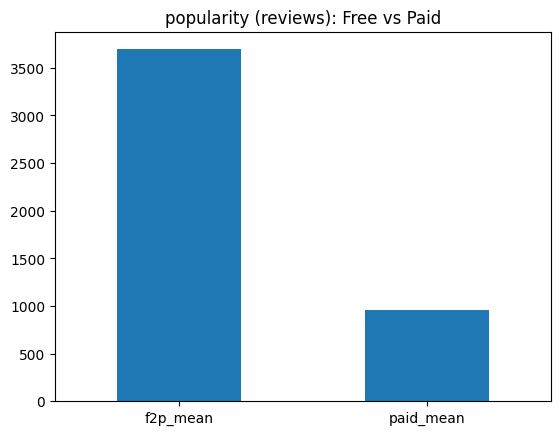

In [8]:
# Visualizations

comparison.loc["popularity"].plot(kind="bar")
plt.title("popularity (reviews): Free vs Paid")
plt.xticks(rotation=0)
plt.show()

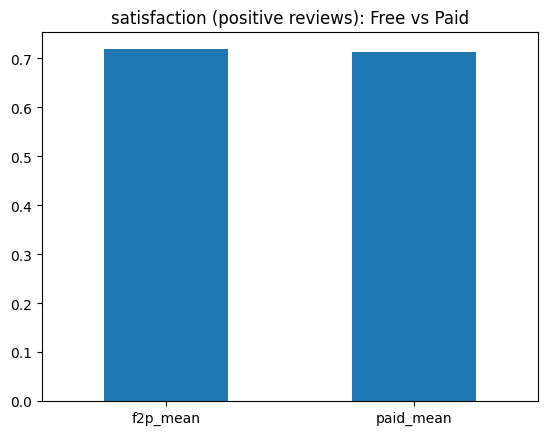

In [9]:
comparison.loc["satisfaction"].plot(kind="bar")
plt.title("satisfaction (positive reviews): Free vs Paid")
plt.xticks(rotation=0)
plt.show()

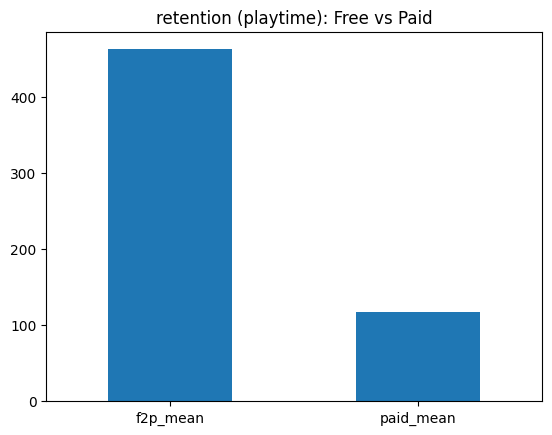

In [10]:
comparison.loc["retention"].plot(kind="bar")
plt.title("retention (playtime): Free vs Paid")
plt.xticks(rotation=0)
plt.show()

In [11]:
# Correlations

f2p_corr = f2p[["total_reviews", "review_score", "average_playtime"]].corr()
f2p_corr

,total_reviews,review_score,average_playtime
total_reviews,1.000000,0.034999,0.118920
review_score,0.034999,1.000000,0.037334
average_playtime,0.118920,0.037334,1.000000


In [12]:
paid_corr = paid[["total_reviews", "review_score", "average_playtime"]].corr()
paid_corr

,total_reviews,review_score,average_playtime
total_reviews,1.000000,0.042256,0.322254
review_score,0.042256,1.000000,0.026124
average_playtime,0.322254,0.026124,1.000000


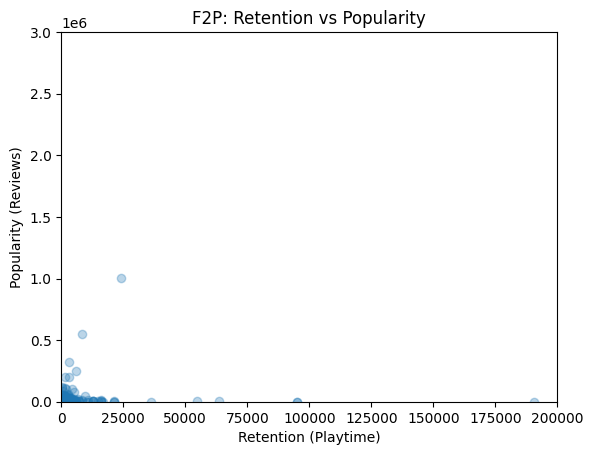

In [13]:
# Scatter plots 

plt.scatter(f2p["average_playtime"], f2p["total_reviews"], alpha= 0.3)
plt.title("F2P: Retention vs Popularity")
plt.xlabel("Retention (Playtime)")
plt.ylabel("Popularity (Reviews)")
plt.xlim(0, 200000)
plt.ylim(0, 3000000)
plt.show()

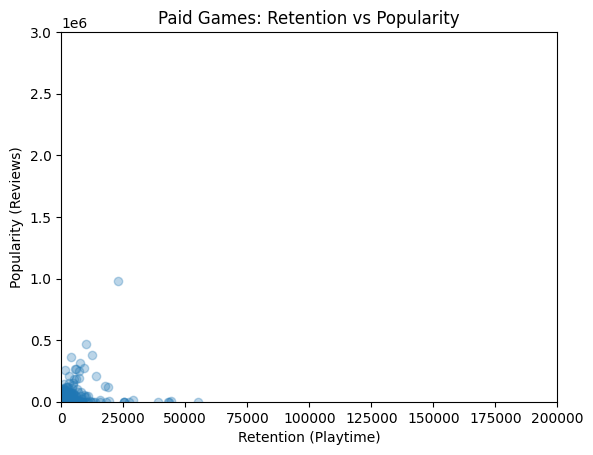

In [14]:
plt.scatter(paid["average_playtime"], paid["total_reviews"], alpha= 0.3)
plt.title("Paid Games: Retention vs Popularity")
plt.xlabel("Retention (Playtime)")
plt.ylabel("Popularity (Reviews)")
plt.xlim(0, 200000)
plt.ylim(0, 3000000)
plt.show()

In [15]:
# Refined KPI 

f2p["success_f2p"] = (
    np.log1p(f2p["total_reviews"]) *
    np.log1p(f2p["average_playtime"]) *
    f2p["review_score"]
)

In [16]:

paid["success_paid"] = (
    np.log1p(paid["total_reviews"]) *
    np.log1p(paid["average_playtime"]) *
    paid["review_score"]
)

## Top games per model

In [17]:
# F2P

f2p.sort_values("success_f2p", ascending=False)[
    ["name", "total_reviews", "average_playtime", "review_score", "success_f2p"]
].head(10)


,name,total_reviews,average_playtime,review_score,success_f2p
25,Counter-Strike: Global Offensive,3046717,22494,0.867952,129.854291
22,Dota 2,1005586,23944,0.858710,119.674226
19,Team Fortress 2,549915,8495,0.938107,112.182138
1634,Warframe,246809,5845,0.917880,98.849765
3362,Unturned,324056,3248,0.902850,92.634161
5390,Clicker Heroes,47264,9742,0.899839,88.954048
1772,Path of Exile,77710,5263,0.921284,88.894169
8969,PRICE,4431,63481,0.947416,87.971329
4931,Eternal Senia,10333,15961,0.978032,87.490131
7509,Iron Snout,14166,10647,0.980446,86.905540


In [18]:
# Paid Games

paid.sort_values("success_paid", ascending=False)[
    ["name", "total_reviews", "average_playtime", "review_score", "success_paid"]
].head(10)


,name,total_reviews,average_playtime,review_score,success_paid
121,Garry's Mod,380154,12422,0.956773,115.889261
0,Counter-Strike,127873,17612,0.973888,111.956869
1120,Terraria,263397,5585,0.970398,104.502133
1025,The Elder Scrolls V: Skyrim,252254,7089,0.940730,103.746120
1127,Arma 3,117558,18823,0.893465,102.670534
1596,Euro Truck Simulator 2,182594,4942,0.968099,99.759767
2031,Rocket League®,264377,5825,0.917481,99.314796
895,Mount & Blade: Warband,78085,7932,0.971659,98.284398
7577,Factorio,48641,10087,0.985136,98.015893
2964,The Witcher® 3: Wild Hunt,207728,3068,0.976902,96.037626


Both free-to-play and paid successful games share a common characteristic: high player engagement. However, free-to-play games achieve this through large-scale multiplayer ecosystems, while paid games rely more on replayability and high-quality gameplay systems.

Now that we know which successful games are on Steam, we need to look at what they have in common to try to replicate it in the future ( Retention Pattern Analysis NB)